In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=Warning)


# Deep Learning Tools
from tensorflow.keras import layers, models
import keras
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPool2D
from keras.layers import Activation, Dropout, BatchNormalization, Flatten, Dense
from keras.optimizers import Adam
from keras.utils import to_categorical


# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
import os
import cv2
from tqdm import tqdm

# Image paths
imagePaths = []

dataset_path = "/content/drive/MyDrive/Colab Notebooks/archive/COVID-19_Radiography_Dataset"

for dirname, _, filenames in os.walk(dataset_path):
    # Only process files inside the 'images' folder
    if 'images' in dirname:
        for filename in filenames:
            if filename.endswith('png'):   # Consider only PNG files
                imagePaths.append(os.path.join(dirname, filename))

print("Total Images:", len(imagePaths))

Total Images: 7735


In [ ]:
Data = []
Target = []
resize = 150

# Label mapping dictionary
cat = {'Viral Pneumonia': 'Pneumonia', 'Normal': 'Normal', 'COVID': 'Covid-19'}

# Iterate through the image paths and assign the labels
for imagePath in tqdm(imagePaths):
    label = imagePath.split(os.path.sep)[-3]  # Extract the label from parent folder

    if label not in cat:
        continue  # Skip this image if label is not found in dictionary

    image = cv2.imread(imagePath, cv2.IMREAD_GRAYSCALE)  # read as grayscale
    image = cv2.resize(image, (resize, resize)) / 255.0  # Normalize image pixels to [0, 1]

    Data.append(image)
    Target.append(cat[label])

print(f"Processed {len(Data)} images with corresponding labels.")

100%|██████████| 7735/7735 [33:12<00:00,  3.88it/s]

Processed 7735 images with corresponding labels.


In [ ]:
# Count number of images in each category

normal_count = Target.count("Normal")
pneumonia_count = Target.count("Pneumonia")
covid_count = Target.count("Covid-19")

print("Normal Images:", normal_count)
print("Pneumonia Images:", pneumonia_count)
print("Covid-19 Images:", covid_count)

Normal Images: 5248
Pneumonia Images: 629
Covid-19 Images: 1858


In [ ]:
print(len(Data))
print(len(Target))

7735
7735


In [ ]:
le = LabelEncoder()
labels = le.fit_transform(Target)
labels = to_categorical(labels)

print(le.classes_)
print(labels[0])

['Covid-19' 'Normal' 'Pneumonia']
[0. 0. 1.]


In [ ]:
(x_train, x_test, y_train, y_test) = train_test_split(Data, labels, test_size=0.20, stratify=labels, random_state=42)

# Further split the training data into training and validation sets
(x_train, x_val, y_train, y_val) = train_test_split(x_train, y_train, test_size=0.20, stratify=y_train, random_state=42)


trainX = np.array(x_train)
valX = np.array(x_val)
testX = np.array(x_test)
trainY = np.array(y_train)
valY = np.array(y_val)
testY = np.array(y_test)

print("Training data shape:", trainX.shape)
print("Validation data shape:", valX.shape)
print("Testing data shape:", testX.shape)
print("Training labels shape:", trainY.shape)
print("Validation labels shape:", valY.shape)
print("Testing labels shape:", testY.shape)

Training data shape: (4950, 150, 150)
Validation data shape: (1238, 150, 150)
Testing data shape: (1547, 150, 150)
Training labels shape: (4950, 3)
Validation labels shape: (1238, 3)
Testing labels shape: (1547, 3)


In [ ]:
s = 150  # Size

model = Sequential()

# Feature Extraction Parts
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu",
                 input_shape=(s, s, 1), kernel_initializer='he_normal'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(1, 1)))

model.add(Dropout(0.25))

# Neural Network (Dense Layers)
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(3, activation="softmax"))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.categorical_crossentropy,
              metrics=['accuracy'])

# Train the model
epochs = 10
history = model.fit(trainX, trainY,
                    epochs=epochs,
                    batch_size=40,
                    verbose=1,
                    validation_data=(valX, valY))

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.7471 - loss: 0.8392 - val_accuracy: 0.8578 - val_loss: 0.3572
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8661 - loss: 0.3265 - val_accuracy: 0.8659 - val_loss: 0.3122
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8980 - loss: 0.2636 - val_accuracy: 0.8958 - val_loss: 0.2551
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9269 - loss: 0.1974 - val_accuracy: 0.9208 - val_loss: 0.2291
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9426 - loss: 0.1528 - val_accuracy: 0.9297 - val_loss: 0.2141
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9588 - loss: 0.1140 - val_accuracy: 0.9410 - val_loss: 0.1885
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9630 - loss: 0.0942 - val_accuracy: 0.9386 - val_loss: 0.2089
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9691 - loss: 0.0844 - val_acc

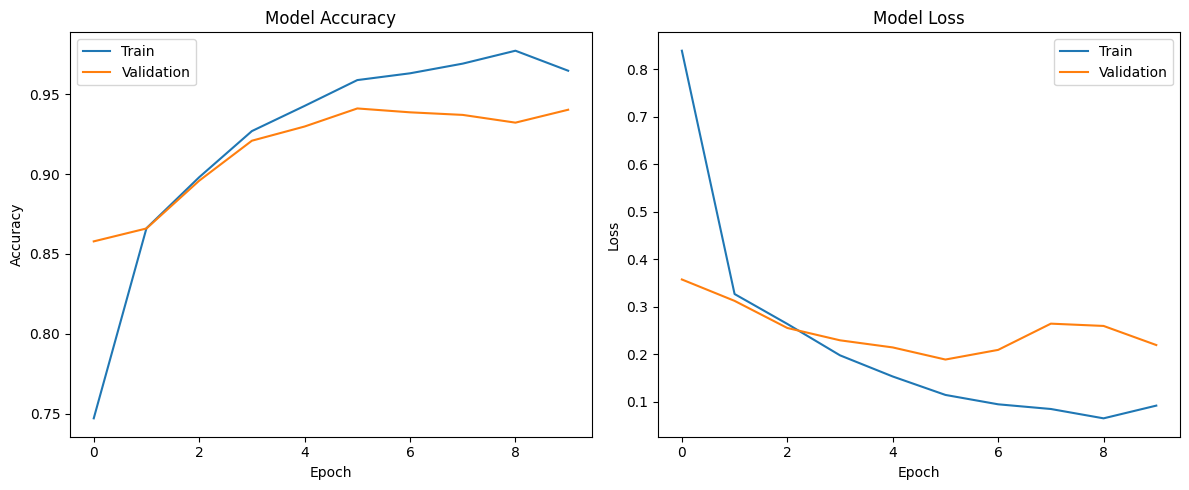

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

In [ ]:
# Make predictions
predictions = model.predict(testX)
y_pred = np.argmax(predictions, axis=1)  # Convert predictions to class labels

# Convert testY from one-hot encoded to class labels (integers)
y_true = np.argmax(testY, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
[[ 322   49    1]
 [  27 1016    6]
 [   3   13  110]]


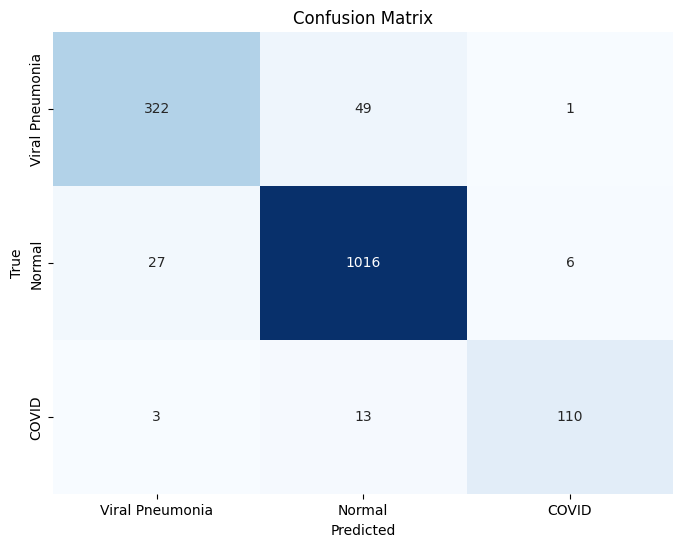

In [ ]:
# Create DataFrame for the confusion matrix
Confusion_Matrix = pd.DataFrame(cm, index=cat, columns=cat)

# Plot the confusion matrix using seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(Confusion_Matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=le.classes_, digits = 5))

              precision    recall  f1-score   support

    Covid-19    0.91477   0.86559   0.88950       372
      Normal    0.94249   0.96854   0.95534      1049
   Pneumonia    0.94017   0.87302   0.90535       126

    accuracy                        0.93601      1547
   macro avg    0.93248   0.90238   0.91673      1547
weighted avg    0.93563   0.93601   0.93543      1547

